# Reducción de dimensionalidad con PCA

Ejemplo de aplicación de Análisis de Componentes Principales (PCA) para reducir la
dimensionalidad de un conjunto de datos. Este ejemplo ha sido adaptado para el curso de aprendizaje de máquinas
no supervisado de la Especialización de Machine Learning de la Universidad del Magdalena.

El código es una simplificación y adaptación de uno de los ejemplos en
<https://github.com/aapatel09/handson-unsupervised-learning>, desarrollado por Ankur Patel.

Se utiliza el conjunto de datos _MNIST_ de dígitos escritos a mano, creado por
Yann LeCun, Corinna Cortes y Christopher J.C. Burges
(<http://yann.lecun.com/exdb/mnist/>). Cada imagen es de 28×28 píxeles. Cada píxel de una imagen es tomado como una variable o _feature_ es decir, cada ejemplo cuenta con 784 dimensiones.

In [1]:
import os
import gzip
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 1. Carga y exploración de los datos

El archivo `mnist.pkl.gz` ya viene dividido en tres particiones:

- Entrenamiento: 50.000 ejemplos
- Validación 10.000 ejemplos
- Prueba: 10 000 ejemplos
  
**Nota:** cualquier transformación de los datos, incluyendo PCA, se debe ajustar únicamente en el conjunto de entrenamiento y luego aplicarse a los conjuntos de validación y prueba. Ajustar con todos los datos resultaría en lo que se llama *data leakage*.

In [2]:
# Cargamos el conjunto de datos MNIST (el archivo esta en la misma carpeta del notebook)
ruta_archivo = os.path.join(os.getcwd(), 'mnist.pkl.gz')

with gzip.open(ruta_archivo, 'rb') as f:
    train_set, validation_set, test_set = pickle.load(f, encoding='latin1')

# Cada particion es una tupla (matriz de caracteristicas X, vector de etiquetas y)
X_train, y_train = train_set[0], train_set[1]
X_validation, y_validation = validation_set[0], validation_set[1]
X_test, y_test = test_set[0], test_set[1]

In [3]:
# Verificamos las dimensiones de cada particion
print("Entrenamiento: %d ejemplos con %d caracteristicas" % X_train.shape)
print("Validacion:    %d ejemplos con %d caracteristicas" % X_validation.shape)
print("Prueba:        %d ejemplos con %d caracteristicas" % X_test.shape)

Entrenamiento: 50000 ejemplos con 784 caracteristicas
Validacion:    10000 ejemplos con 784 caracteristicas
Prueba:        10000 ejemplos con 784 caracteristicas


In [4]:
# Convertimos los arreglos a DataFrames de pandas para facilitar su manipulación.
# Usamos índices consecutivos entre particiones para que no se repitan.
train_index = range(0, len(X_train))
validation_index = range(len(X_train), len(X_train) + len(X_validation))
test_index = range(len(X_train) + len(X_validation), len(X_train) + len(X_validation) + len(X_test))

X_train = pd.DataFrame(data=X_train, index=train_index)
y_train = pd.Series(data=y_train, index=train_index)

X_validation = pd.DataFrame(data=X_validation, index=validation_index)
y_validation = pd.Series(data=y_validation, index=validation_index)

X_test = pd.DataFrame(data=X_test, index=test_index)
y_test = pd.Series(data=y_test, index=test_index)

X_train.describe()

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.0,50000.0,50000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000739,0.000354,0.000204,0.000090,0.000071,0.000009,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.022778,0.015422,0.012079,0.007217,0.007181,0.001483,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.992188,0.992188,0.988281,0.988281,0.992188,0.242188,0.0,0.0,0.0,0.0


Estadísticas descriptivas de la matriz de entrenamiento.
Observe que: 
(1) los píxeles ya están escalados al rango [0, 1], y
(2) muchas columnas (bordes de la imagen) son siempre 0, es decir, tienen varianza cero y no aportan información.

In [5]:
# Las etiquetas son los dígitos del 0 al 9 (10 clases)
y_train.unique()

array([5, 0, 4, 1, 9, 2, 3, 6, 7, 8])

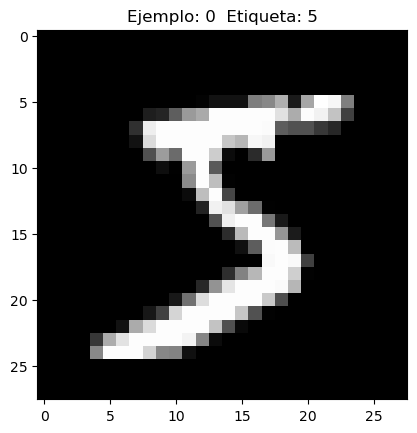

In [6]:
def ver_digito(ejemplo):
    """Muestra la imagen 28x28 del ejemplo indicado junto con su etiqueta."""
    etiqueta = y_train.loc[ejemplo]
    imagen = X_train.loc[ejemplo, :].values.reshape([28, 28])
    plt.title('Ejemplo: %d  Etiqueta: %d' % (ejemplo, etiqueta))
    plt.imshow(imagen, cmap='gray')
    plt.show()

# Visualizamos el primer digito del conjunto de entrenamiento
ver_digito(0)

Al tratar cada píxel como una variable, terminamos con 784 variables, pero muchas no aportan información: los píxeles de los bordes valen 0 en *todas* las imágenes (varianza cero) y muchos otros casi nunca cambian. Esta redundancia es justamente la que PCA aprovecha para reducir la dimensionalidad.

In [7]:
# Varianza de cada píxel (variable) a lo largo de los 50000 ejemplos de entrenamiento
varianza_pixeles = X_train.var(axis=0)

n_total = X_train.shape[1]
n_constantes = (varianza_pixeles == 0).sum()
n_casi_constantes = (varianza_pixeles < 0.01).sum()

print("Número total de variables (píxeles):  %d" % n_total)
print("Variables constantes (varianza cero): %d" % n_constantes)
print("Variables con varianza menor a 0.01:  %d" % n_casi_constantes)

Número total de variables (píxeles):  784
Variables constantes (varianza cero): 67
Variables con varianza menor a 0.01:  341


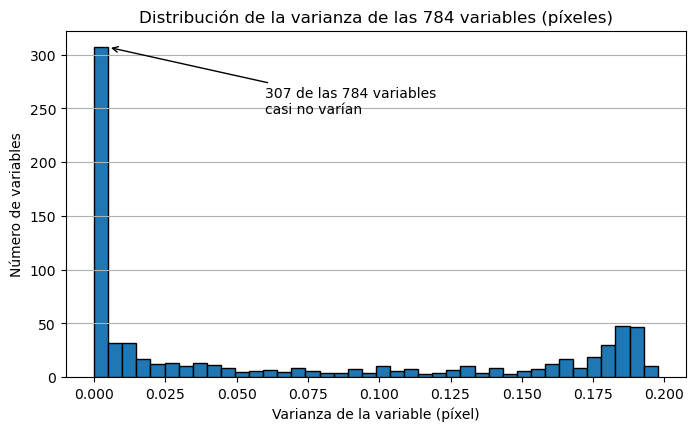

In [8]:
# Histograma de las varianzas de las 784 variables: una gran cantidad de
# píxeles tiene varianza prácticamente cero, es decir, casi no cambian
# entre imágenes y por tanto aportan poca información.
plt.figure(figsize=(8, 4.5))
conteos, bordes, _ = plt.hist(varianza_pixeles, bins=40, edgecolor='black')
plt.xlabel('Varianza de la variable (píxel)')
plt.ylabel('Número de variables')
plt.title('Distribución de la varianza de las 784 variables (píxeles)')
plt.annotate('%d de las 784 variables\ncasi no varían' % conteos[0],
             xy=(bordes[1], conteos[0]),
             xytext=(0.06, conteos[0] * 0.8),
             arrowprops=dict(arrowstyle='->'))
plt.grid(True, axis='y')
plt.show()

## 2. Análisis de Componentes Principales (PCA)

PCA busca nuevas variables los componentes principales que son combinaciones
lineales de las variables originales, ordenadas de mayor a menor varianza explicada.
Proyectar los datos sobre las primeras $k$ componentes permite representar cada ejemplo
con solo $k$ números en lugar de 784, perdiendo la menor cantidad de información posible
(en el sentido de varianza).

**Notas metodológicas:**

1. Centrado: PCA requiere datos centrados (media cero por variable). La implementación de `sklearn` resta la media automáticamente, así que no hay que hacerlo a mano.
2. Escalado: cuando las variables tienen unidades o escalas distintas, se debe estandarizar primero (p. ej. con `StandardScaler`), porque PCA es sensible a la escala. En este ejemplo no es necesario escalar porque todas las variables son píxeles en la misma escala $[0, 1]$.
3. Sin fuga de información: el PCA se ajusta (`fit`) solo con el conjunto de entrenamiento. Los conjuntos de    validación y prueba únicamente se transforman (`transform`) con el mismo modelo.

Primero ajustamos un PCA con todas las componentes (784) para estudiar cuánta varianza explica cada una y decidir cuántas conservar.

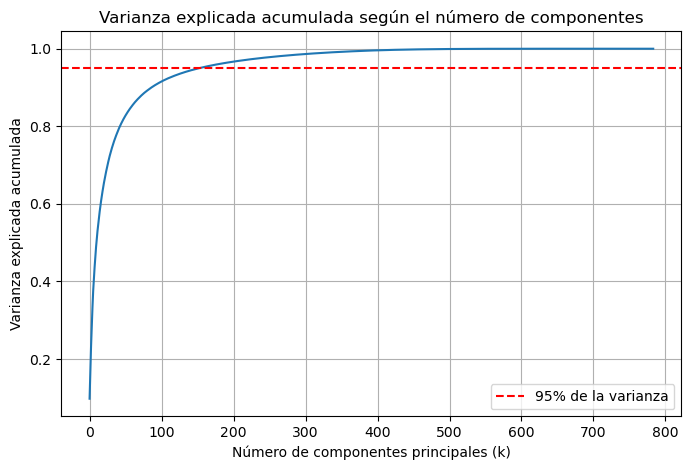

In [9]:
from sklearn.decomposition import PCA

pca_completo = PCA() #Esta función realizará todos los pasos que vimos en las diapositivas
pca_completo.fit(X_train)

# Varianza explicada acumulada: cuánto explican las primeras k componentes en conjunto
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(varianza_acumulada)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% de la varianza')
plt.xlabel('Número de componentes principales (k)')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada según el número de componentes')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Porcentaje de varianza capturada por las primeras k componentes
for k in [50, 100, 150, 200, 250, 300, 784]:
    print('Varianza capturada por las primeras %3d componentes: %.4f'
          % (k, varianza_acumulada[k - 1]))

Varianza capturada por las primeras  50 componentes: 0.8249
Varianza capturada por las primeras 100 componentes: 0.9147
Varianza capturada por las primeras 150 componentes: 0.9484
Varianza capturada por las primeras 200 componentes: 0.9665
Varianza capturada por las primeras 250 componentes: 0.9781
Varianza capturada por las primeras 300 componentes: 0.9862
Varianza capturada por las primeras 784 componentes: 1.0000


### Selección del número de componentes

Un criterio habitual es conservar las componentes necesarias para explicar un alto porcentaje se la varianza (por ejemplo 95%). `sklearn` permite pasar ese porcentaje directamente como `n_components=0.95` y calcula $k$ automáticamente.

In [11]:
# PCA que conserva el 95% de la varianza, ajustado con entrenamiento
pca = PCA(n_components=0.95)

# fit_transform: ajusta con entrenamiento y lo proyecta al nuevo espacio
X_train_PCA = pca.fit_transform(X_train)
X_train_PCA = pd.DataFrame(data=X_train_PCA, index=train_index)

# transform (SIN fit): proyectamos validacion con el PCA ajustado en entrenamiento
X_validation_PCA = pca.transform(X_validation)
X_validation_PCA = pd.DataFrame(data=X_validation_PCA, index=validation_index)

# El conjunto de prueba se transforma igual, con el PCA ya ajustado en entrenamiento
X_test_PCA = pca.transform(X_test)
X_test_PCA = pd.DataFrame(data=X_test_PCA, index=test_index)

print("Componentes necesarios para explicar el 95%% de la varianza: %d" % pca.n_components_)
print("Dimensión original de entrenamiento: ", X_train.shape)
print("Dimensión reducida de entrenamiento: ", X_train_PCA.shape)
print("Dimensión reducida de validación:    ", X_validation_PCA.shape)

Componentes necesarios para explicar el 95% de la varianza: 154
Dimensión original de entrenamiento:  (50000, 784)
Dimensión reducida de entrenamiento:  (50000, 154)
Dimensión reducida de validación:     (10000, 154)


### Visualización en dos dimensiones

Aunque conservamos ~150 componentes, los dos primeros ya permiten visualizar la estructura de los datos. Visualicemos la separación de las clases usando los dos primeros componentes principales frente a dos píxeles originales cualesquiera.

Nota: Observe que en este ejemplo solo estamos utilizando las variables a predecir ó clase de los ejemplos para visualizar.

In [12]:
def grafico_dispersion(X, y, nombre_algoritmo, col1, col2):
    """Gráfica dos columnas de X coloreando cada punto según su etiqueta y."""
    temp = pd.DataFrame(data=X.loc[:, [col1, col2]], index=X.index)
    temp = pd.concat((temp, y), axis=1, join="inner")
    v1, v2 = f"Componente_{col1}", f"Componente_{col2}"
    temp.columns = [v1, v2, "Etiqueta"]
    sns.lmplot(x=v1, y=v2, hue="Etiqueta", data=temp, fit_reg=False)
    ax = plt.gca()
    ax.set_title("Separación de las observaciones usando " + nombre_algoritmo)
    plt.show()

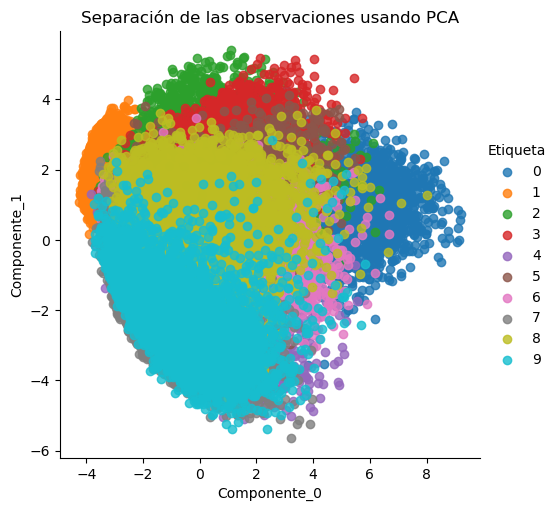

In [13]:
# Las dos primeras componentes principales ya separan parcialmente algunos dígitos
grafico_dispersion(X_train_PCA, y_train, "PCA", 0, 1)

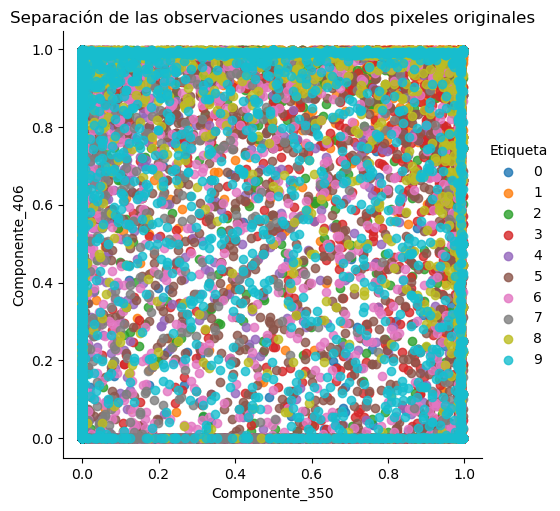

In [14]:
# En contraste, dos pixeles originales tomados al azar (columnas 350 y 406)
# no muestran ninguna estructura: la informacion esta repartida entre los 784 pixeles.
grafico_dispersion(X_train, y_train, "dos pixeles originales", 350, 406)

### Reconstrucción de imágenes

Toda proyección PCA puede "invertirse" de forma aproximada: a partir de las $k$
componentes se reconstruye la imagen en el espacio original de 784 píxeles
($\hat{x} = \mu + \sum_{j=1}^{k} z_j \, v_j$). Cuantas más componentes se usan,
mejor es la reconstrucción. Esto muestra visualmente cuánta información retiene
cada valor de $k$.

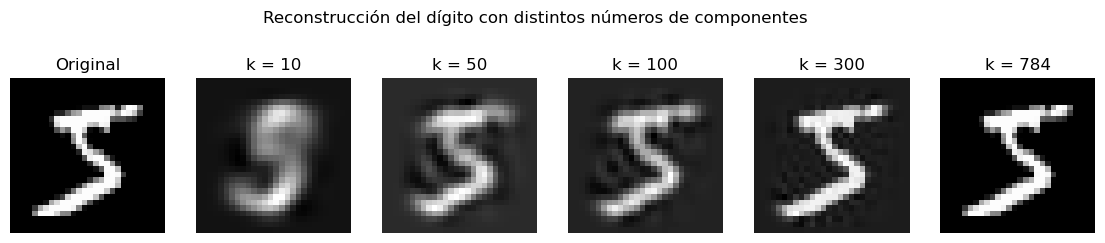

In [15]:
# Reconstruimos un mismo dígito usando distintos números de componentes k
ejemplo = 0
valores_k = [10, 50, 100, 300, 784]

# Proyectamos el ejemplo sobre las 784 componentes del PCA completo
z = pca_completo.transform(X_train.iloc[[ejemplo]])[0]

fig, ejes = plt.subplots(1, len(valores_k) + 1, figsize=(14, 3))

# Imagen original
ejes[0].imshow(X_train.iloc[ejemplo].values.reshape(28, 28), cmap='gray')
ejes[0].set_title('Original')
ejes[0].axis('off')

# Reconstruccion con las primeras k componentes: media + suma de k componentes
for eje, k in zip(ejes[1:], valores_k):
    x_reconstruido = pca_completo.mean_ + z[:k] @ pca_completo.components_[:k, :]
    eje.imshow(x_reconstruido.reshape(28, 28), cmap='gray')
    eje.set_title('k = %d' % k)
    eje.axis('off')

plt.suptitle('Reconstrucción del dígito con distintos números de componentes')
plt.show()

## 3. Kernel PCA

PCA solo captura estructura lineal. Kernel PCA aplica el "truco del kernel" para hacer PCA en un espacio de características de mayor dimensión definido implícitamente por un kernel (aquí el kernel gaussiano o RBF), lo que le permite capturar relaciones no lineales.

Su costo computacional crece con el cuadrado del número de ejemplos (construye una matriz de kernel de $N \times N$), por lo que aquí lo ajustamos con una submuestra de 10 000 ejemplos de entrenamiento y luego transformamos todos los datos con ese modelo ajustado.

In [16]:
from sklearn.decomposition import KernelPCA

# Kernel PCA con kernel gaussiano (RBF), limitado a 100 componentes
kernelPCA = KernelPCA(n_components=100, kernel='rbf')

# Ajustamos con una submuestra de 10000 ejemplos por costo computacional
kernelPCA.fit(X_train.iloc[:10000])

# Transformamos entrenamiento y validación con el modelo ya ajustado
X_train_kernelPCA = kernelPCA.transform(X_train)
X_train_kernelPCA = pd.DataFrame(data=X_train_kernelPCA, index=train_index)

X_validation_kernelPCA = kernelPCA.transform(X_validation)
X_validation_kernelPCA = pd.DataFrame(data=X_validation_kernelPCA, index=validation_index)

# El conjunto de prueba se transforma igual, con el modelo ya ajustado en entrenamiento
X_test_kernelPCA = kernelPCA.transform(X_test)
X_test_kernelPCA = pd.DataFrame(data=X_test_kernelPCA, index=test_index)

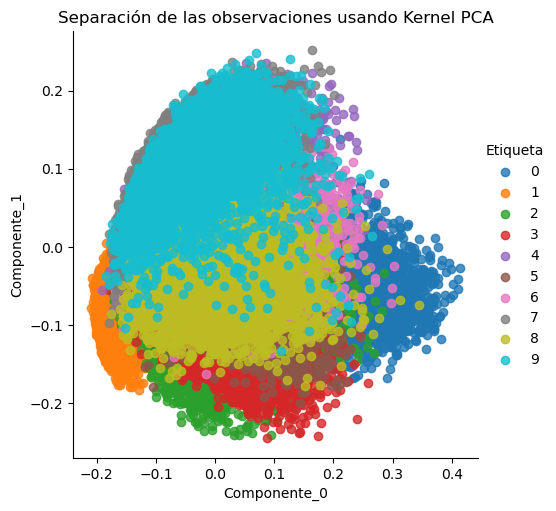

In [17]:
# Visualizamos los dos primeros componentes del Kernel PCA
grafico_dispersion(X_train_kernelPCA, y_train, "Kernel PCA", 0, 1)

### Comparación visual entre PCA clásico y Kernel PCA

Al comparar esta gráfica con la del PCA clásico se observan más similitudes que diferencias:

- Similitudes: en ambos casos los dos primeros componentes revelan una estructura parecida. Algunos dígitos forman grupos compactos en los extremos (por ejemplo el 1 y el 0), mientras que el resto se traslapa en la zona central. Con solo dos componentes ninguno de los dos métodos logra separar por completo las diez clases.

- Escala de los ejes: los valores no son comparables entre métodos. En el PCA clásico los componentes son combinaciones lineales de los píxeles y sus valores se mueven en un rango amplio; en el Kernel PCA los componentes viven en el espacio implícito definido por el kernel y sus valores resultan mucho más pequeños. Lo relevante es la posición relativa de los puntos, no la magnitud de los ejes.

La lección importante es que un método no lineal no siempre supera al lineal: su ventaja depende del kernel elegido y de sus parámetros (por ejemplo `gamma` en el kernel RBF), que en la práctica deben ajustarse para cada problema.